# Strongly Coupled

This tutorial demonstrates a **strongly coupled** controlled pendulum assembled from FMI 2.0 Co-Simulation FMUs wrapped by `FMUComponent`.

It is *strongly coupled* because there is an **algebraic loop** between the drive and pendulum subsystems: the pendulum acceleration depends directly on the drive torque, and the drive torque depends directly on the pendulum acceleration.


## Overview

We build a closed-loop pendulum controller with the following FMU-based components:

- `ref`: reference trajectory generator
- `sensor_ref`: encoder on the reference signal
- `sensor_state`: encoder on the pendulum angle
- `pid`: continuous PID controller
- `drive`: actuator dynamics and limits (with direct feedthrough)
- `pendulum`: physical pendulum model (with direct feedthrough)

**Theory highlights (strong coupling):**

- The drive and pendulum share kinematics (`q`, `omega`, `alpha`), which introduces a *higher-index constraint* at the acceleration level.
- The pendulum acceleration `alpha` depends instantaneously on the drive torque.
- The drive torque depends instantaneously on the pendulum acceleration (e.g., via a prescribed-motion element and elastic coupling).
- This creates an **algebraic loop** with no causal ordering; iterative resolution is required.
- Explicit co-simulation can become unstable unless the step size is very small; loop-solving algorithms mitigate this.


## Learning Goals

By the end of this tutorial, you should be able to:

- assemble a strongly coupled FMU-based closed-loop system
- identify algebraic loops and direct-feedthrough ports
- understand why strong coupling requires iterative loop resolution
- visualize the system graph and interpret loop-highlighted edges
- run a simulation and inspect component histories


## Prerequisites and Setup

We rely on:

- `syssimx`
- `numpy`
- `pandas`
- `matplotlib`
- `graphviz` (optional, for the system diagram)


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from syssimx import FMUComponent, System, Connection
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

## Discover FMUs

In [10]:
repo_root = Path().cwd().parent.parent.parent
fmu_dir = repo_root / "demos/ControlledPendulum/MyModels/FMUs"

fmu_files = sorted(fmu_dir.glob("*.fmu"))
fmu_paths = {f.stem: f for f in fmu_files}

## System Assembly

In [3]:
ref = FMUComponent(name="ref", fmu_path=fmu_paths["Reference"], group="Reference")
sensor_ref = FMUComponent(name="sensor_ref", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
sensor_state = FMUComponent(name="sensor_state", fmu_path=fmu_paths["AngleEncoder"], group="Sensors")
pid = FMUComponent(name="pid", fmu_path=fmu_paths["PID_Continuous"], group="Control")
drive_coupled = FMUComponent(name="drive", fmu_path=fmu_paths["Drive_Coupled"], group="Actuator")
pendulum = FMUComponent(name="pendulum", fmu_path=fmu_paths["Pendulum"], group="Plant")

components = [ref, sensor_ref, sensor_state, pid, drive_coupled, pendulum]

In [4]:
c1 = Connection(
    src_comp=ref.name,
    src_port=ref.output_specs["q_ref"].name,
    dst_comp=sensor_ref.name,
    dst_port=sensor_ref.input_specs["q"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["q"].name,
    dst_comp=sensor_state.name,
    dst_port=sensor_state.input_specs["q"].name,
)

c3 = Connection(
    src_comp=sensor_ref.name,
    src_port=sensor_ref.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["ref"].name,
)

c4 = Connection(
    src_comp=sensor_state.name,
    src_port=sensor_state.output_specs["U_q"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["y"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive_coupled.name,
    dst_port=drive_coupled.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive_coupled.name,
    src_port=drive_coupled.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["torque"].name,
)

c7a = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["q"].name,
    dst_comp=drive_coupled.name,
    dst_port=drive_coupled.input_specs["phi"].name,
)
c7b = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive_coupled.name,
    dst_port=drive_coupled.input_specs["omega"].name,
)
c7c = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["alpha"].name,
    dst_comp=drive_coupled.name,
    dst_port=drive_coupled.input_specs["alpha"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7a, c7b, c7c]

## Initialize and Inspect Coupling

We initialize once, then inspect execution order and algebraic loops.

We detect one algebraic loop involving the `drive` and `pendulum` components.

In [5]:
system = System(name="Strongly Coupled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [12]:
print("Execution Order (generations):")
for gen in system.execution_order:
    print(gen)

print("\nAlgebraic Loops:")
for loop in system.algebraic_loops:
    print(loop)

Execution Order (generations):
['drive', 'pendulum', 'ref']
['sensor_ref', 'sensor_state']
['pid']

Algebraic Loops:
['pendulum', 'drive']


## Visualize the System Graph

This diagram is useful for verifying signal flow and for communicating model structure.

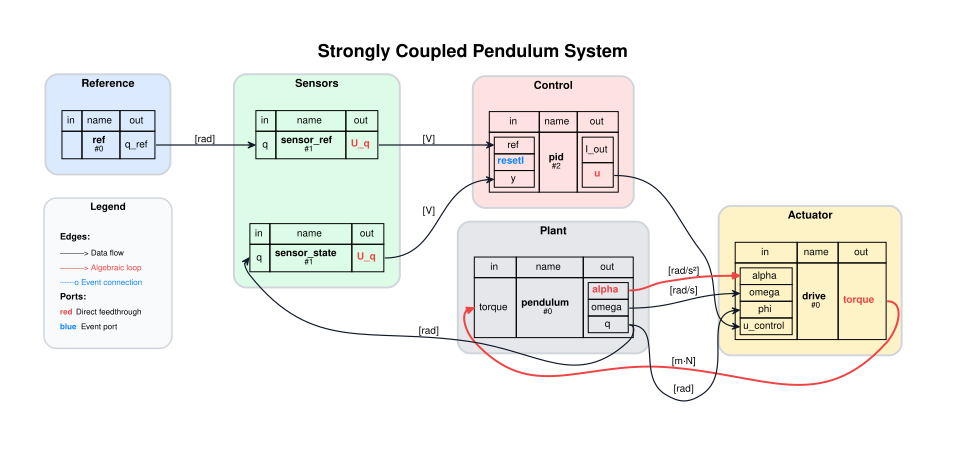

In [6]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize("strongly_coupled_system_graph.svg")

## Run the Simulation

In [7]:
system.run(t0=0.0, tf=10.0, dt=0.01)
history = system.get_history()

def get_series(history, comp: str, port: str):
    t, data = history.get(comp)
    return t, np.asarray(data[port])

t_ref, q_ref = get_series(history, "ref", "q_ref")
t_q, q = get_series(history, "pendulum", "q")
t_u, u = get_series(history, "pid", "u")

## Plotting Results

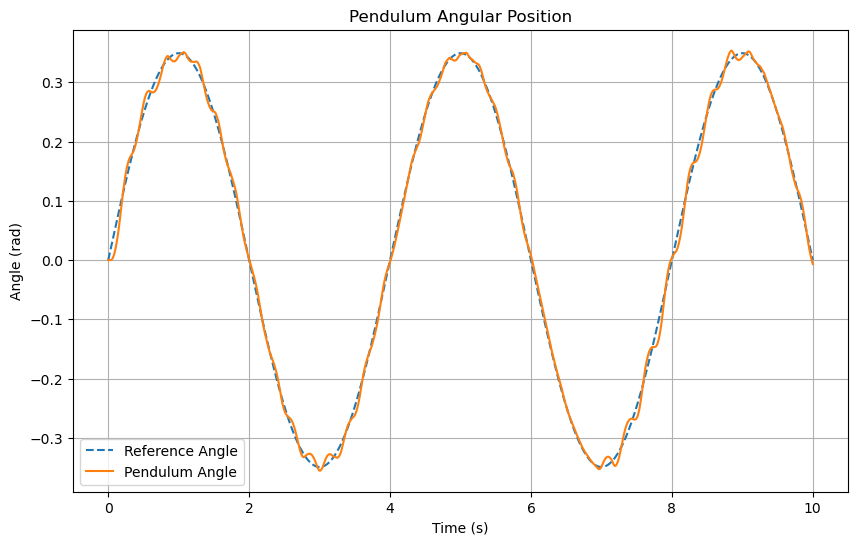

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(t_ref, q_ref, "--", label="Reference Angle")
plt.plot(t_q, q, label="Pendulum Angle")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title("Pendulum Angular Position")
plt.grid(True)
plt.legend()
plt.show()